# Telco Customer Churn Analysis

This notebook performs an end-to-end analysis of the Telco Customer Churn dataset. The goal of this analysis is to understand the factors that contribute to customer churn and to build a predictive model to identify customers who are likely to leave.

The workflow is divided into three main sections:
1. **Data Preprocessing:** Loading the data, handling missing values, creating new features, and encoding categorical variables.
2. **Exploratory Data Analysis (EDA):** Visualizing distributions and relationships between features to uncover patterns related to churn.
3. **Modeling and Evaluation:** Training a Random Forest classifier to predict churn, evaluating its performance using various metrics (Accuracy, Precision, Recall, F1-Score), identifying key predictors, and validating the model with cross-validation.

## Load packages and set up

In [ ]:
from google.colab import drive
import pandas as pd
from sklearn.preprocessing import OneHotEncoder, MinMaxScaler
from sklearn.model_selection import train_test_split, cross_validate
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from matplotlib import pyplot as plt
import seaborn as sns
import scipy.stats as stats
from imblearn.over_sampling import SMOTE
import numpy as np

In [ ]:
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


## 1. Data preprocessing

### Load the dataset and check it

In [ ]:
dataset = pd.read_csv('/content/drive/MyDrive/Datasets/Telco-Customer-Churn.csv')
dataset.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


This dataset has 7043 entries and 21 features.

### Check missing values and incorrect data types

In [ ]:
# Find missing values
message = dataset.isnull().sum().sum()
print(f'There are {message} missing values in the dataset.')

There are 0 missing values in the dataset.


In [ ]:
# Check data types
dataset['TotalCharges'] = pd.to_numeric(dataset['TotalCharges'], errors='coerce')
dataset['TotalCharges'] = dataset['TotalCharges'].fillna(dataset['TotalCharges'].median())

The feature "TotalCharges" is supposed to be float. After converting, there are 11 missing values. Replace them by the median of this column.

### Create new features

In [ ]:
# Divide "Tenure" into group
dataset['Tenure_group'] = pd.cut(dataset['tenure'], bins = [0, 12, 24, float('inf')], labels = ['0 ~ 12 months', '12 ~ 24 months', 'More than 24 months'])

In [ ]:
dataset.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn,Tenure_group
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No,0 ~ 12 months
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,No,No,No,One year,No,Mailed check,56.95,1889.50,No,More than 24 months
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes,0 ~ 12 months
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No,More than 24 months
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes,0 ~ 12 months


### Transform categorical variables

Change all binary variables to 1 and 0 (except "gender").

In [ ]:
prep_data = dataset.copy()
prep_data[['Partner', 'Dependents', 'PhoneService', 'PaperlessBilling', 'Churn']] = prep_data[['Partner', 'Dependents', 'PhoneService', 'PaperlessBilling', 'Churn']].replace({'Yes': 1, 'No': 0})

<ipython-input-74-a1d3d9f18b2f>:2: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  prep_data[['Partner', 'Dependents', 'PhoneService', 'PaperlessBilling', 'Churn']] = prep_data[['Partner', 'Dependents', 'PhoneService', 'PaperlessBilling', 'Churn']].replace({'Yes': 1, 'No': 0})


Use One-Hot Encoding on other categorical variables.

In [ ]:
prep_data = pd.get_dummies(prep_data, columns = ['gender', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaymentMethod'], dtype = int)
prep_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 44 columns):
 #   Column                                   Non-Null Count  Dtype   
---  ------                                   --------------  -----   
 0   customerID                               7043 non-null   object  
 1   SeniorCitizen                            7043 non-null   int64   
 2   Partner                                  7043 non-null   int64   
 3   Dependents                               7043 non-null   int64   
 4   tenure                                   7043 non-null   int64   
 5   PhoneService                             7043 non-null   int64   
 6   PaperlessBilling                         7043 non-null   int64   
 7   MonthlyCharges                           7043 non-null   float64 
 8   TotalCharges                             7043 non-null   float64 
 9   Churn                                    7043 non-null   int64   
 10  Tenure_group                        

### Create another new feature

In [ ]:
# Get the service count
prep_data['Service_count'] = prep_data[['OnlineSecurity_Yes', 'OnlineBackup_Yes', 'DeviceProtection_Yes', 'TechSupport_Yes', 'StreamingTV_Yes', 'StreamingMovies_Yes']].sum(axis = 1)

### Create normalized version of relevant variables

In [ ]:
scaler = MinMaxScaler()
prep_data[['tenure', 'MonthlyCharges', 'TotalCharges']] = scaler.fit_transform(prep_data[['tenure', 'MonthlyCharges', 'TotalCharges']])

## 2. Exploratory data analysis

### Analyse univariate key features by plots

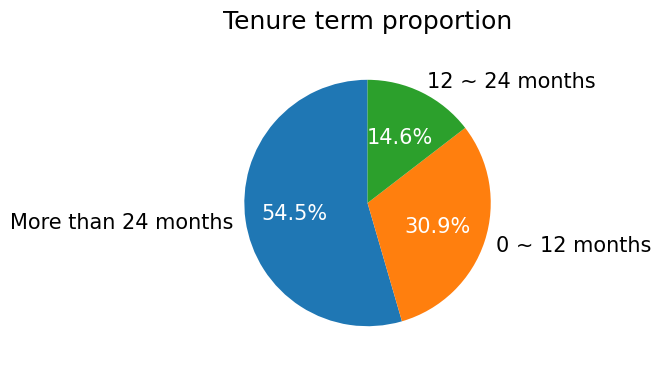

In [ ]:
plt.figure(figsize=(6, 4))

_, _, autotexts = plt.pie(dataset['Tenure_group'].value_counts(), labels = ['More than 24 months', '0 ~ 12 months', '12 ~ 24 months'], autopct="%1.1f%%", startangle=90,
        textprops={"fontsize": 15} )

for autotext in autotexts:
    autotext.set_color("white")

plt.title("Tenure term proportion", fontsize=18, pad = 15)
plt.show()

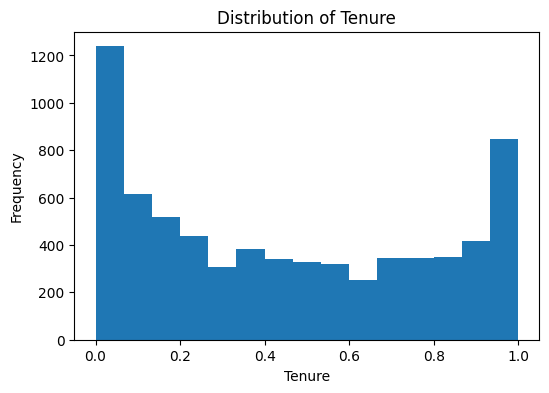

In [ ]:
plt.figure(figsize = (6, 4))
plt.hist(prep_data['tenure'], bins = 15)
plt.xlabel('Tenure')
plt.ylabel('Frequency')
plt.title('Distribution of Tenure')
plt.show()

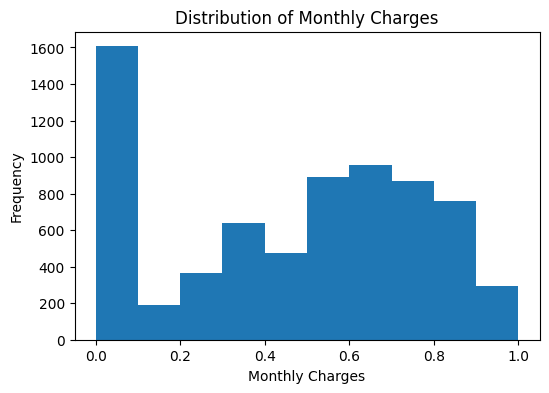

In [ ]:
plt.figure(figsize = (6, 4))
plt.hist(prep_data['MonthlyCharges'], bins = 10)
plt.xlabel('Monthly Charges')
plt.ylabel('Frequency')
plt.title('Distribution of Monthly Charges')
plt.show()

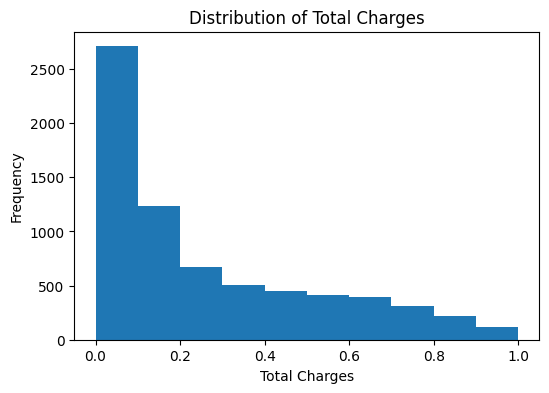

In [ ]:
plt.figure(figsize = (6, 4))
plt.hist(prep_data['TotalCharges'], bins = 10)
plt.xlabel('Total Charges')
plt.ylabel('Frequency')
plt.title('Distribution of Total Charges')
plt.show()

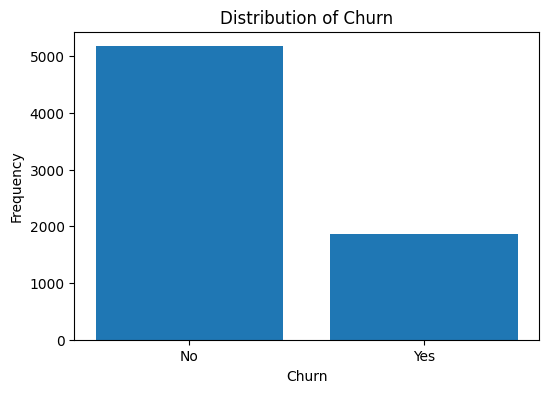

In [ ]:
plt.figure(figsize = (6, 4))
plt.bar(prep_data['Churn'].value_counts().index, prep_data['Churn'].value_counts())
plt.xlabel('Churn')
plt.ylabel('Frequency')
plt.xticks([0, 1], ['No', 'Yes'])
plt.title('Distribution of Churn')
plt.show()

In [ ]:
dataset[]

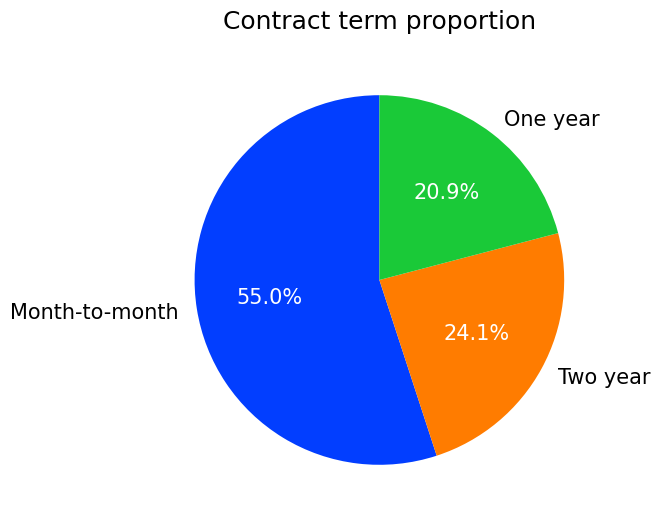

In [ ]:
plt.figure(figsize=(8, 6))

_, _, autotexts = plt.pie(dataset['Contract'].value_counts(), labels = dataset['Contract'].value_counts().index, autopct="%1.1f%%", startangle=90,
        colors= sns.color_palette('bright'), textprops={"fontsize": 15} )

for autotext in autotexts:
    autotext.set_color("white")

plt.title("Contract term proportion", fontsize=18, pad = 15)
plt.show()

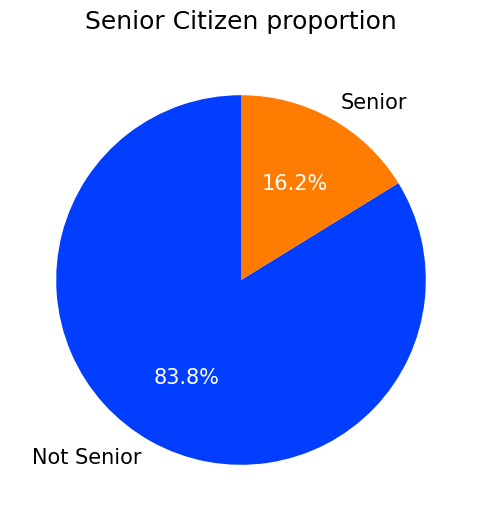

In [ ]:
plt.figure(figsize=(8, 6))

_, _, autotexts = plt.pie(dataset['SeniorCitizen'].value_counts(), labels = ['Not Senior', 'Senior'], autopct="%1.1f%%", startangle=90,
        colors= sns.color_palette('bright'), textprops={"fontsize": 15} )

for autotext in autotexts:
    autotext.set_color("white")

plt.title("Senior Citizen proportion", fontsize=18, pad = 15)
plt.show()

### Analyse relationships between features and churn

In [ ]:
temp = dataset[dataset['Churn'] == 'Yes'].groupby(['Tenure_group', 'Contract']).size().reset_index(name='Count')

plt.figure(figsize=(8, 6))
sns.barplot(x='Tenure_group', y = 'Count', hue="Contract", data=temp, dodge=True, palette='bright')
plt.title("Tenure term and Contract of existing customers", fontsize=18, pad = 15)
plt.xlabel("Tenure term", fontsize=12, labelpad = 10)
plt.ylabel("Frequency", fontsize=12, labelpad = 10)
plt.show()

<ipython-input-94-4ff575e9121d>:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x = 'Churn', y = 'Service_count', data = prep_data, palette='Set2')


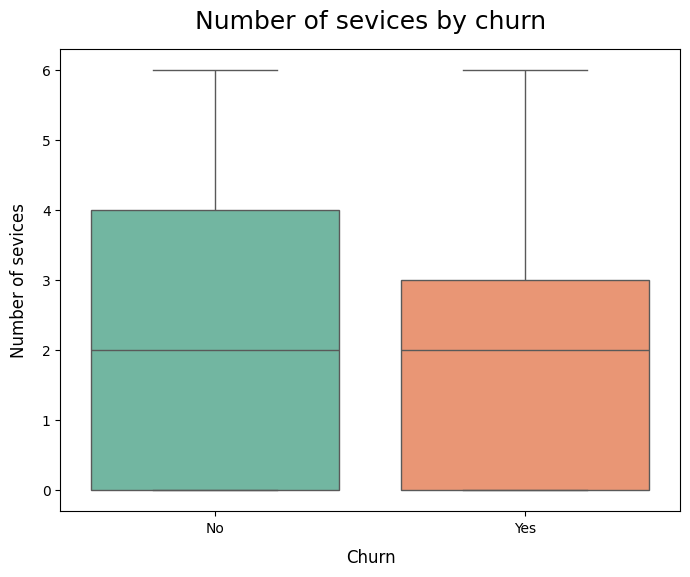

In [ ]:
plt.figure(figsize = (8, 6))
sns.boxplot(x = 'Churn', y = 'Service_count', data = prep_data, palette='Set2')
plt.xlabel("Churn", fontsize=12, labelpad = 10)
plt.ylabel("Number of sevices", fontsize=12, labelpad = 10)
plt.title("Number of sevices by churn", fontsize=18, pad = 15)
plt.xticks([0, 1], ['No', 'Yes'])
plt.show()

In [ ]:
# T test
test_1 = prep_data[prep_data['Churn'] == 1]['Service_count']
test_2 = prep_data[prep_data['Churn'] == 0]['Service_count']
_, p_value = stats.ttest_ind(test_1, test_2)

print(f"P-value: {p_value}")

P-value: 1.6713743645878483e-13


In [ ]:
sns.color_palette('bright')[0]

(0.00784313725490196, 0.24313725490196078, 1.0)

<ipython-input-117-a5419a72e1e8>:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  temp = dataset[dataset['Churn'] == 'Yes'].groupby(['Tenure_group', 'Contract']).size().reset_index(name='Count')


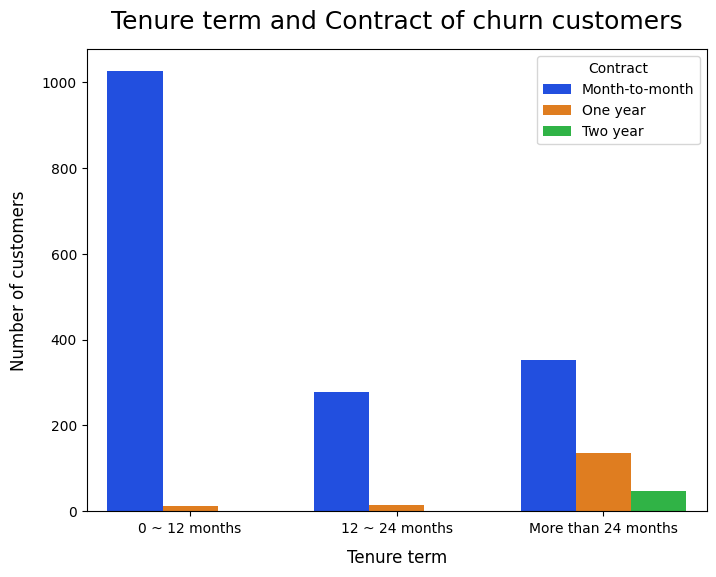

In [ ]:
temp = dataset[dataset['Churn'] == 'Yes'].groupby(['Tenure_group', 'Contract']).size().reset_index(name='Count')

plt.figure(figsize=(8, 6))
sns.barplot(x='Tenure_group', y = 'Count', hue="Contract", data=temp, dodge=True, palette='bright')
plt.title("Tenure term and Contract of churn customers", fontsize=18, pad = 15)
plt.xlabel("Tenure term", fontsize=12, labelpad = 10)
plt.ylabel("Number of customers", fontsize=12, labelpad = 10)
plt.show()

<ipython-input-116-39f9fdf9f615>:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  temp = dataset[dataset['Churn'] == 'No'].groupby(['Tenure_group', 'Contract']).size().reset_index(name='Count')


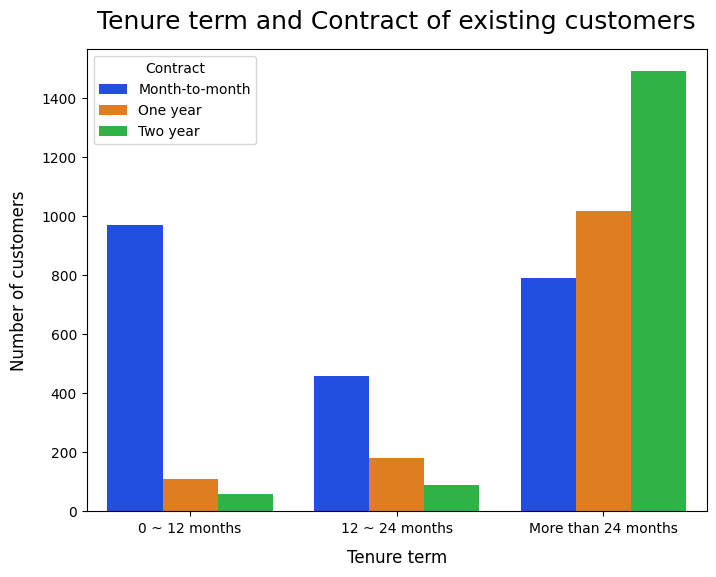

In [ ]:
temp = dataset[dataset['Churn'] == 'No'].groupby(['Tenure_group', 'Contract']).size().reset_index(name='Count')

plt.figure(figsize=(8, 6))
sns.barplot(x='Tenure_group', y = 'Count', hue="Contract", data=temp, dodge=True, palette='bright')
plt.title("Tenure term and Contract of existing customers", fontsize=18, pad = 15)
plt.xlabel("Tenure term", fontsize=12, labelpad = 10)
plt.ylabel("Number of customers", fontsize=12, labelpad = 10)
plt.show()

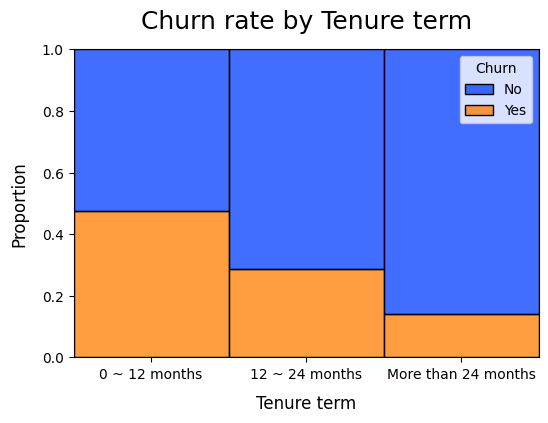

In [ ]:
plt.figure(figsize = (6, 4))
sns.histplot(x = 'Tenure_group', hue = 'Churn', data = dataset, stat='percent', multiple='fill', palette='bright')
plt.xlabel("Tenure term", fontsize=12, labelpad = 10)
plt.ylabel("Proportion", fontsize=12, labelpad = 10)
plt.title("Churn rate by Tenure term", fontsize=18, pad = 15)
plt.show()

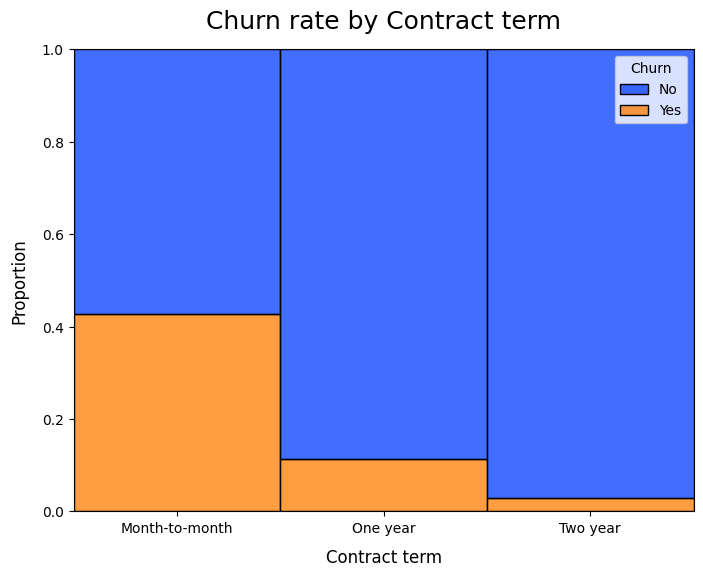

In [ ]:
plt.figure(figsize = (8, 6))
sns.histplot(x = 'Contract', hue = 'Churn', data = dataset, stat='percent', multiple='fill', palette='bright')
plt.xlabel("Contract term", fontsize=12, labelpad = 10)
plt.ylabel("Proportion", fontsize=12, labelpad = 10)
plt.title("Churn rate by Contract term", fontsize=18, pad = 15)
plt.show()

<ipython-input-23-0d2acb0772a2>:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x = 'Churn', y = 'TotalCharges', data = dataset, palette='Set2')


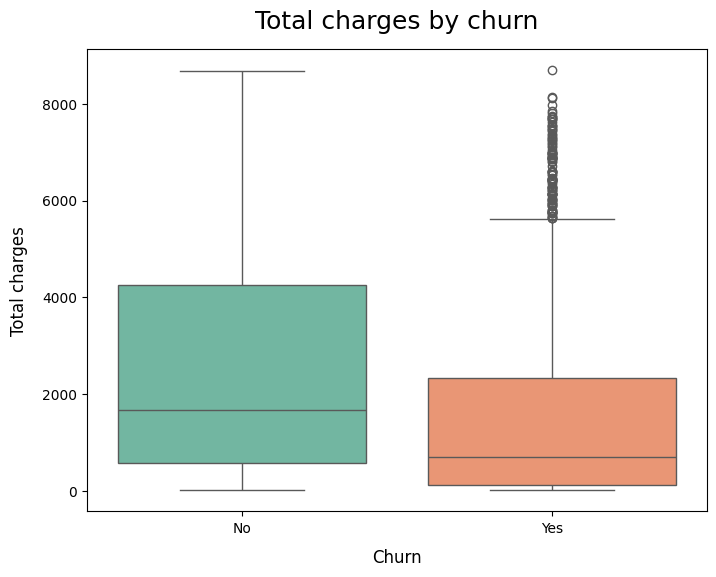

In [ ]:
plt.figure(figsize = (8, 6))
sns.boxplot(x = 'Churn', y = 'TotalCharges', data = dataset, palette='Set2')
plt.xlabel("Churn", fontsize=12, labelpad = 10)
plt.ylabel("Total charges", fontsize=12, labelpad = 10)
plt.title("Total charges by churn", fontsize=18, pad = 15)
plt.show()

<ipython-input-114-97059319c16c>:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x = 'Churn', y = 'MonthlyCharges', data = dataset, palette='Set2')


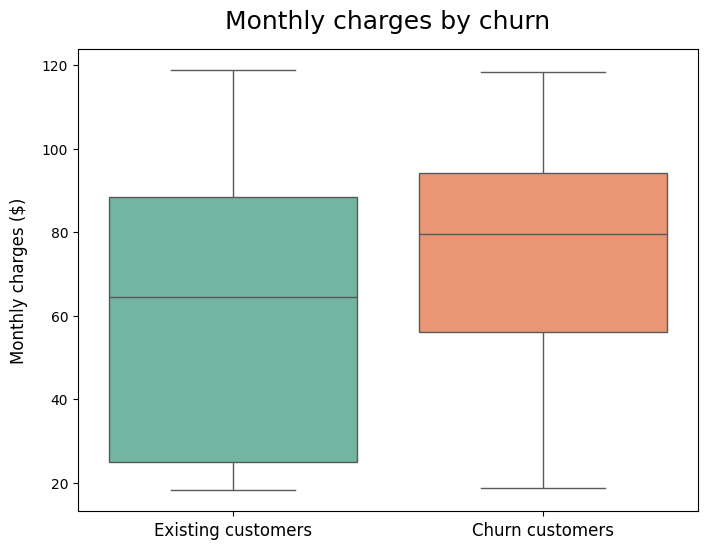

In [ ]:
plt.figure(figsize = (8, 6))
sns.boxplot(x = 'Churn', y = 'MonthlyCharges', data = dataset, palette='Set2')
plt.xlabel("")
plt.ylabel("Monthly charges ($)", fontsize=12, labelpad = 10)
plt.title("Monthly charges by churn", fontsize=18, pad = 15)
plt.xticks(['No', 'Yes'], ['Existing customers', 'Churn customers'], fontsize = 12)
plt.show()

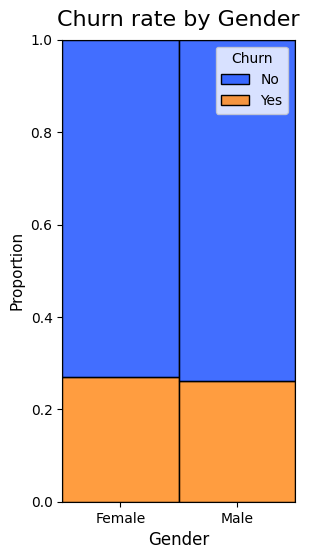

In [ ]:
plt.figure(figsize = (3, 6))
sns.histplot(x = 'gender', hue = 'Churn', data = dataset, stat='percent', multiple='fill', palette='bright')
plt.xlabel("Gender", fontsize=12)
plt.ylabel("Proportion", fontsize=11)
plt.title("Churn rate by Gender", fontsize=16, pad = 10)
plt.show()

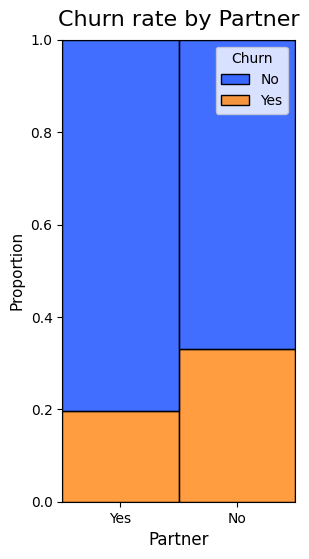

In [ ]:
plt.figure(figsize = (3, 6))
sns.histplot(x = 'Partner', hue = 'Churn', data = dataset, stat='percent', multiple='fill', palette='bright')
plt.xlabel("Partner", fontsize=12)
plt.ylabel("Proportion", fontsize=11)
plt.title("Churn rate by Partner", fontsize=16, pad = 10)
plt.show()

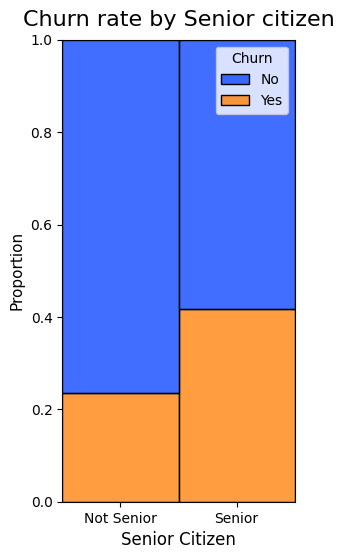

In [ ]:
dataset['SeniorCitizen'] = dataset['SeniorCitizen'].replace({0: 'Not Senior', 1: 'Senior'})

plt.figure(figsize = (3, 6))
sns.histplot(x = 'SeniorCitizen', hue = 'Churn', data = dataset, stat='percent', multiple='fill', palette='bright')
plt.xlabel("Senior Citizen", fontsize=12)
plt.ylabel("Proportion", fontsize=11)
plt.title("Churn rate by Senior citizen", fontsize=16, pad = 10)

plt.show()

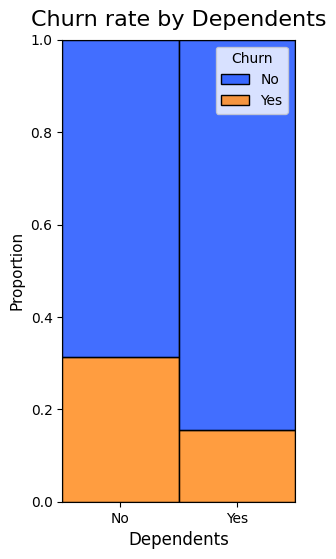

In [ ]:
plt.figure(figsize = (3, 6))
sns.histplot(x = 'Dependents', hue = 'Churn', data = dataset, stat='percent', multiple='fill', palette='bright')
plt.xlabel("Dependents", fontsize=12)
plt.ylabel("Proportion", fontsize=11)
plt.title("Churn rate by Dependents", fontsize=16, pad = 10)
plt.show()

**Relationship between partner and churn**

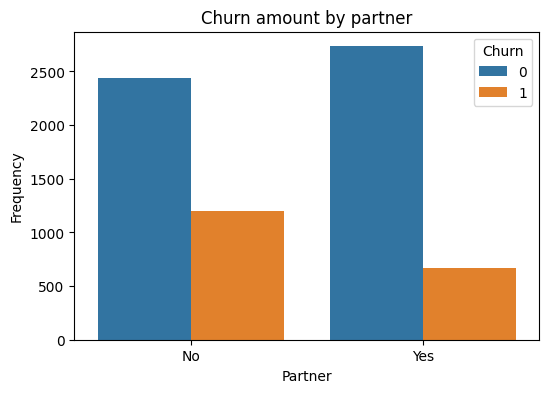

In [ ]:
plt.figure(figsize = (6, 4))
sns.countplot(x = 'Partner', hue = 'Churn', data = prep_data)
plt.title("Churn amount by partner")
plt.xlabel("Partner")
plt.ylabel("Frequency")
plt.xticks([0, 1], ['No', 'Yes'])
plt.show()

Customers who don't have partners are more likely to leave.

In [ ]:
# Chi square test
test = pd.crosstab(prep_data['Partner'], prep_data['Churn'])
_, p, _, _ = stats.chi2_contingency(test)
print(f'The p-value is {p}')

The p-value is 2.1399113440759935e-36


p value is really low. They have association.

**Relationship between dependents and churn**

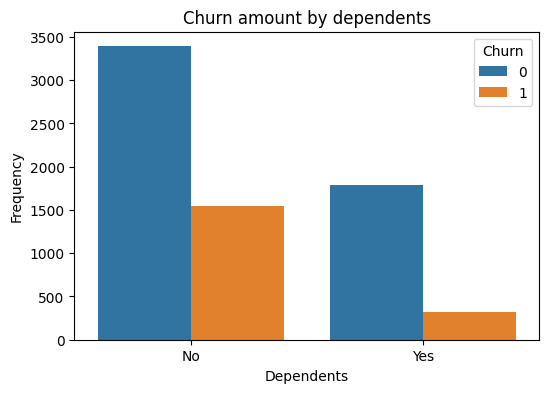

In [ ]:
plt.figure(figsize = (6, 4))
sns.countplot(x = 'Dependents', hue = 'Churn', data = prep_data)
plt.title("Churn amount by dependents")
plt.xlabel("Dependents")
plt.ylabel("Frequency")
plt.xticks([0, 1], ['No', 'Yes'])
plt.show()

Customers who don't have dependents are more likely to leave.

In [ ]:
# Chi square test
test = pd.crosstab(prep_data['Dependents'], prep_data['Churn'])
_, p, _, _ = stats.chi2_contingency(test)
print(f'The p-value is {p}')

The p-value is 4.9249216612154196e-43


The p value is pretty low which mean they have correlation.

**Relationship between tenure group and churn**

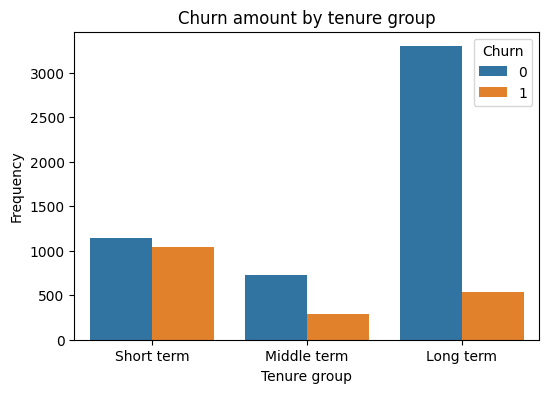

In [ ]:
plt.figure(figsize = (6, 4))
sns.countplot(x = 'Tenure_group', hue = 'Churn', data = prep_data)
plt.title("Churn amount by tenure group")
plt.xlabel("Tenure group")
plt.ylabel("Frequency")
plt.xticks([0, 1, 2], ['Short term', 'Middle term', 'Long term'])
plt.show()

The longer time customers stay, the lower probability they leave.

In [ ]:
# Chi square test
test = pd.crosstab(prep_data['Tenure_group'], prep_data['Churn'])
_, p, _, _ = stats.chi2_contingency(test)
print(f'The p-value is {p}')

The p-value is 4.32298939601873e-176


The p value is pretty low which means they have correlation

**Relationship between PaperlessBilling and churn**

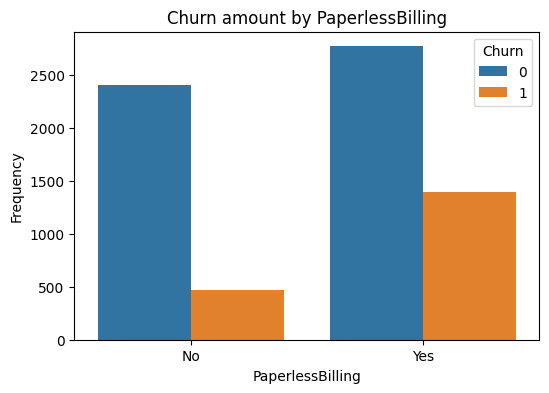

In [ ]:
plt.figure(figsize = (6, 4))
sns.countplot(x = 'PaperlessBilling', hue = 'Churn', data = prep_data)
plt.title("Churn amount by PaperlessBilling")
plt.xlabel("PaperlessBilling")
plt.ylabel("Frequency")
plt.xticks([0, 1], ['No', 'Yes'])
plt.show()

If a customer has paperless billing, he is more likely to leave.

In [ ]:
# Chi square test
test = pd.crosstab(prep_data['PaperlessBilling'], prep_data['Churn'])
_, p, _, _ = stats.chi2_contingency(test)
print(f'The p-value is {p}')

The p-value is 4.073354668665985e-58


There is an association between this two variables.

**Relationship between Monthly charges and churn**

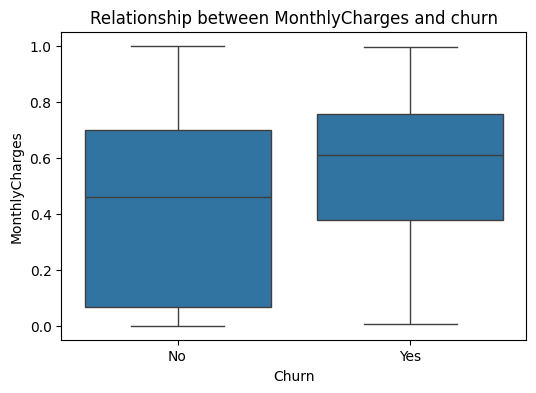

In [ ]:
plt.figure(figsize = (6, 4))
sns.boxplot(x = 'Churn', y = 'MonthlyCharges', data = prep_data)
plt.title("Relationship between MonthlyCharges and churn")
plt.xlabel("Churn")
plt.ylabel("MonthlyCharges")
plt.xticks([0, 1], ['No', 'Yes'])
plt.show()

We can see that the customers who left generally have higher monthly changes.

In [ ]:
# T test
test_1 = prep_data[prep_data['Churn'] == 1]['MonthlyCharges']
test_2 = prep_data[prep_data['Churn'] == 0]['MonthlyCharges']
_, p_value = stats.ttest_ind(test_1, test_2)

print(f"P-value: {p_value}")

P-value: 2.706645606887566e-60


Low p value means they have association.

**Relationship between Total changes and churn**

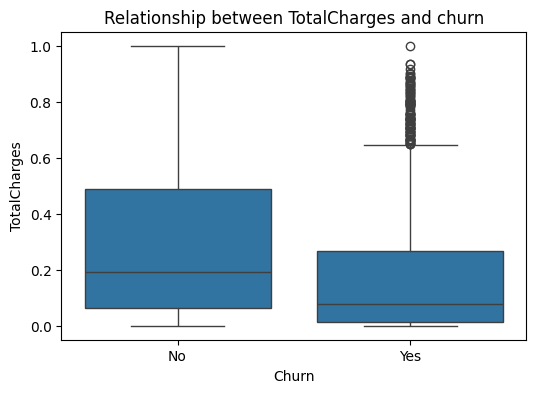

In [ ]:
plt.figure(figsize = (6, 4))
sns.boxplot(x = 'Churn', y = 'TotalCharges', data = prep_data)
plt.title("Relationship between TotalCharges and churn")
plt.xlabel("Churn")
plt.ylabel("TotalCharges")
plt.xticks([0, 1], ['No', 'Yes'])
plt.show()

We can see that the customers who left generally have lower total changes.

In [ ]:
# T test
test_1 = prep_data[prep_data['Churn'] == 1]['TotalCharges']
test_2 = prep_data[prep_data['Churn'] == 0]['TotalCharges']
_, p_value = stats.ttest_ind(test_1, test_2)

print(f"P-value: {p_value}")

P-value: 7.508609056707797e-64


We can see that the customers who left generally have lower total changes.

**Relationship between service number and churn**

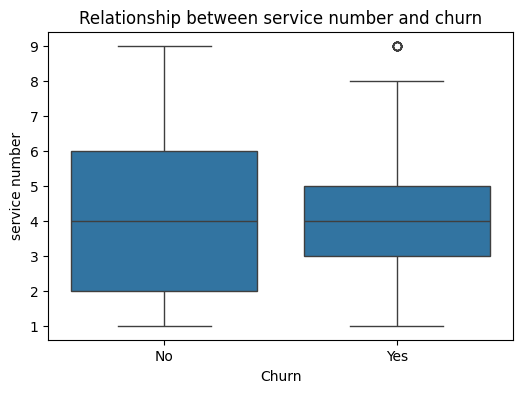

In [ ]:
plt.figure(figsize = (6, 4))
sns.boxplot(x = 'Churn', y = 'Service_count', data = prep_data)
plt.title("Relationship between service number and churn")
plt.xlabel("Churn")
plt.ylabel("service number")
plt.xticks([0, 1], ['No', 'Yes'])
plt.show()

In [ ]:
# T test
test_1 = prep_data[prep_data['Churn'] == 1]['Service_count']
test_2 = prep_data[prep_data['Churn'] == 0]['Service_count']
_, p_value = stats.ttest_ind(test_1, test_2)

print(f"P-value: {p_value}")

P-value: 0.10398191606244465


There is no obvious association between these two variables

**Relationship between gender and churn**

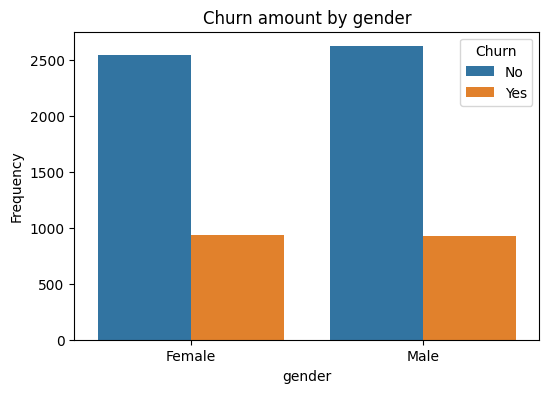

In [ ]:
plt.figure(figsize = (6, 4))
sns.countplot(x = 'gender', hue = 'Churn', data = dataset)
plt.title("Churn amount by gender")
plt.xlabel("gender")
plt.ylabel("Frequency")
plt.show()

In [ ]:
# Chi square test
test = pd.crosstab(dataset['gender'], dataset['Churn'])
_, p, _, _ = stats.chi2_contingency(test)
print(f'The p-value is {p}')

The p-value is 0.48657873605618596


There is no obvious association between these two variables.

**Relationship between contract and churn**

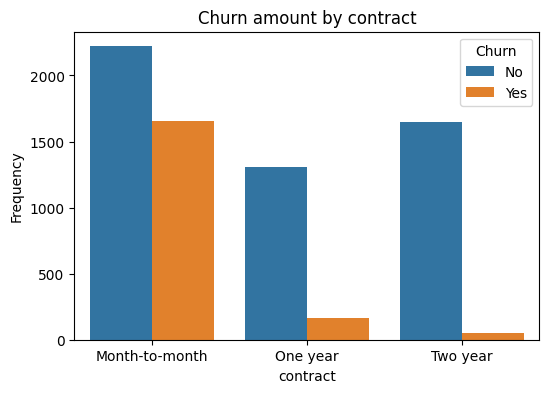

In [ ]:
plt.figure(figsize = (6, 4))
sns.countplot(x = 'Contract', hue = 'Churn', data = dataset)
plt.title("Churn amount by contract")
plt.xlabel("contract")
plt.ylabel("Frequency")
plt.show()

We can see for month to month contract, it has a really high churn rate.

In [ ]:
# Chi square test
test = pd.crosstab(dataset['Contract'], dataset['Churn'])
_, p, _, _ = stats.chi2_contingency(test)
print(f'The p-value is {p}')

The p-value is 5.863038300673391e-258


They have association.

## 3. Modeling and evaluation

Process the dataset again

In [ ]:
# Drop "customerID"
prep_data.drop(['customerID', 'Tenure_group', 'Service_count'], axis = 1, inplace = True)

# Split the data
X_train, X_test, y_train, y_test = train_test_split(prep_data.loc[:, prep_data.columns != 'Churn'], prep_data['Churn'], test_size = 0.2, random_state = 936)

In [ ]:
prep_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 42 columns):
 #   Column                                   Non-Null Count  Dtype  
---  ------                                   --------------  -----  
 0   SeniorCitizen                            7043 non-null   int64  
 1   Partner                                  7043 non-null   int64  
 2   Dependents                               7043 non-null   int64  
 3   tenure                                   7043 non-null   float64
 4   PhoneService                             7043 non-null   int64  
 5   PaperlessBilling                         7043 non-null   int64  
 6   MonthlyCharges                           7043 non-null   float64
 7   TotalCharges                             7043 non-null   float64
 8   Churn                                    7043 non-null   int64  
 9   gender_Female                            7043 non-null   int64  
 10  gender_Male                              7043 no

In [ ]:
smote = SMOTE(sampling_strategy='auto')
X_resamp, y_resamp = smote.fit_resample(X_train, y_train)

Train the model

In [ ]:
rf = RandomForestClassifier(n_estimators = 1000, random_state = 936)
rf.fit(X_train, y_train)

y_pred = rf.predict(X_test)

Evaluate the model

In [ ]:
#Accuracy
accuracy = accuracy_score(y_test, y_pred)

#Precision
precision = precision_score(y_test, y_pred)

#Recall
recall = recall_score(y_test, y_pred)

#F1 Score
f1 = f1_score(y_test, y_pred)

print(f"Accuracy: {accuracy:.2f}")
print(f"Precision: {precision:.2f}")
print(f"Recall: {recall:.2f}")
print(f"F1 Score: {f1:.2f}")

Accuracy: 0.80
Precision: 0.63
Recall: 0.49
F1 Score: 0.55


Identify the key predictors

In [ ]:
importances = rf.feature_importances_
key_pred = pd.DataFrame({'Feature': X_train.columns, 'Importance': importances})
key_pred = key_pred.sort_values(by = 'Importance', ascending = False)
key_pred

,Feature,Importance
7,TotalCharges,0.167245
6,MonthlyCharges,0.145780
3,tenure,0.144271
34,Contract_Month-to-month,0.051288
16,OnlineSecurity_No,0.032674
25,TechSupport_No,0.030919
39,PaymentMethod_Electronic check,0.029612
14,InternetService_Fiber optic,0.026119
5,PaperlessBilling,0.024046
1,Partner,0.022610


Validate model performance using cross-validation

In [ ]:
model = RandomForestClassifier(random_state = 936)
scoring = ['accuracy', 'precision', 'recall', 'f1']  # List of metrics
scores = cross_validate(model, X_train, y_train, cv=5, scoring=scoring)

print(f"Accuracy: {scores['test_accuracy'].mean():.2f}")
print(f"Precision: {scores['test_precision'].mean():.2f}")
print(f"Recall: {scores['test_recall'].mean():.2f}")
print(f"F1 Score: {scores['test_f1'].mean():.2f}")

Accuracy: 0.79
Precision: 0.63
Recall: 0.50
F1 Score: 0.55
